# REPAIR: REgression with Permutation Alignment via variational InfeRence

## Vignette

This notebook demonstrates **REPAIR**, a variational-inference method for
spatial regression when both the covariate–outcome and the outcome–location
links within spatial blocks are unknown.

### Problem Setup

Consider $N = B \times K$ observations partitioned into $B$ spatial blocks of
size $K$.  Within block $i$, outcomes $\mathbf{Y}_i \in \mathbb{R}^K$ are
observed at $K$ spatial locations, and covariates $\mathbf{X}_i \in \mathbb{R}^K$
are measured at $K$ (possibly different) sites, but the within-block
correspondence between covariate records and outcome records is **unknown**.
The data-generating model is

$$\mathbf{Y}_i = \boldsymbol{\pi}_X \mathbf{X}_i \beta
               + \boldsymbol{\pi}_S \mathbf{W}_i
               + \boldsymbol{\varepsilon}_i, \qquad i = 1, \ldots, B,$$

where

- $\boldsymbol{\pi}_X, \boldsymbol{\pi}_S \in \mathcal{S}_K$ are **latent
  within-block permutation matrices** shared across all blocks,
- $\mathbf{W} = (\mathbf{W}_1^\top, \ldots, \mathbf{W}_B^\top)^\top
  \sim \mathrm{GP}(\mathbf{0},\, \sigma^2 C(\cdot;\phi))$ is a latent
  spatial field with Matérn ($\nu = 1/2$) covariance
  $C(h;\phi) = \exp(-\phi\, h)$, and
- $\boldsymbol{\varepsilon}_i \overset{\text{iid}}{\sim}
  N(\mathbf{0},\, \tau^2 \mathbf{I}_K)$.

**REPAIR** jointly recovers $(\boldsymbol{\pi}_X, \boldsymbol{\pi}_S,
\beta, \phi, \sigma^2, \tau^2)$ via mean-field variational inference with
Gumbel–softmax relaxation of the permutation variables and temperature
annealing.

### Three methods compared

| Method | Assumption |
|--------|------------|
| **FullGP** | True locations and links known — oracle gold standard |
| **ArealGP** | Ignores within-block links; uses block-averaged data |
| **REPAIR** | Infers both permutations from data — the proposed method |

In [1]:
import sys, os
sys.path.insert(0, 'src')   # make src/ importable from repo root

import torch
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

# High-level wrappers (documented in src/helper_functions.py)
from helper_functions import (
    generate_synthetic_data,
    train_oracle_gp,
    train_areal_gp,
    run_vigp_unlinked,
    permutation_accuracy,
    summarise_results,
)

torch.manual_seed(0)
np.random.seed(0)
print("Imports OK")

Imports OK


## 1. Generate Synthetic Data

We create a $B = 9$ block grid (3 × 3, auto-detected), each block containing
$K = 5$ locations, for a total of $N = 45$ observations.  Any rectangular
layout works: e.g. `B=6` gives a 2 × 3 grid, `B=12` gives 3 × 4.  The same
random within-block permutations $\boldsymbol{\pi}_X$ and $\boldsymbol{\pi}_S$
are applied independently to covariates and spatial locations, respectively.

In [7]:
B, n_i = 50, 5   # any B works: 6 → 2×3, 12 → 3×4, 9 → 3×3, etc.

data = generate_synthetic_data(
    B=B, n_i=n_i,
    beta_true=4.0,
    phi_true=2.0,
    sigmasq_true=1.0,
    tausq_true=0.2,
    seed=42,
    n_rows=10, n_cols=5,  # optional: override auto layout
)

N = data["N"]
print(f"N = {N}  ({B} blocks in a {data['n_rows']}×{data['n_cols']} grid, "
      f"{n_i} locations per block)")
print(f"True parameters:  β = {data['beta_true']},  φ = {data['phi_true']},  "
      f"σ² = {data['sigmasq_true']},  τ² = {data['tausq_true']}")
print(f"\nTrue X-permutation π_X:\n{data['perm_matrix_x'].numpy().astype(int)}")
print(f"\nTrue S-permutation π_S:\n{data['perm_matrix_s'].numpy().astype(int)}")

N = 250  (50 blocks in a 10×5 grid, 5 locations per block)
True parameters:  β = 4.0,  φ = 2.0,  σ² = 1.0,  τ² = 0.2

True X-permutation π_X:
[[0 0 0 0 1]
 [0 0 1 0 0]
 [0 1 0 0 0]
 [1 0 0 0 0]
 [0 0 0 1 0]]

True S-permutation π_S:
[[0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [0 1 0 0 0]
 [1 0 0 0 0]]


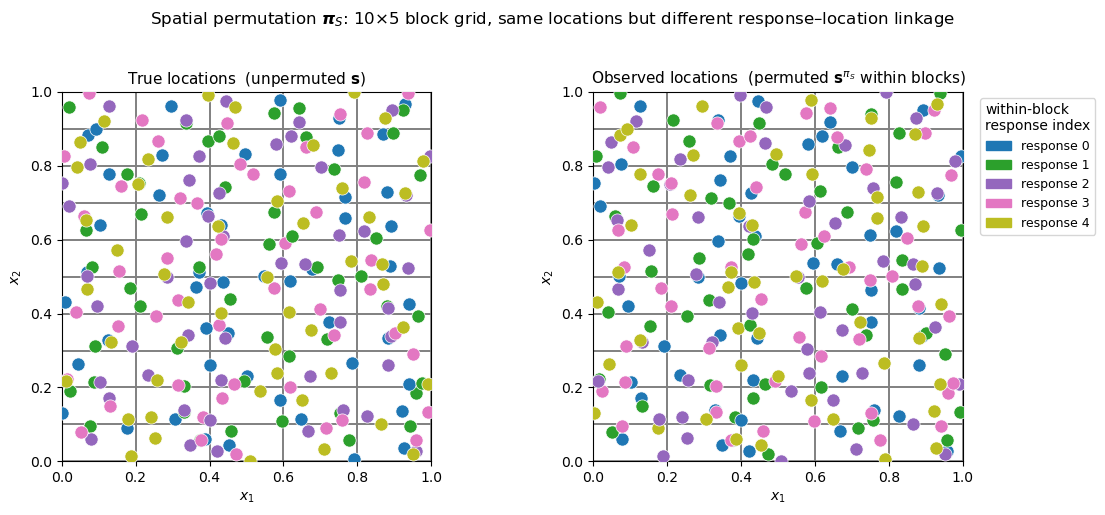

In [8]:
# ── Visualise the spatial permutation effect ──────────────────────────────
# Color each point by its WITHIN-BLOCK response index (0…K-1).
# Left panel:  response j is plotted at its TRUE location  s[b*K + j].
# Right panel: response j is plotted at its OBSERVED location s_perm[b*K + j]
#              = s[b*K + perm_s[j]], so the colours shuffle within each block,
#              making the permutation effect visible.

K      = data["n_i"]
n_rows = data["n_rows"]
n_cols = data["n_cols"]
ra     = data["region_assignments"].numpy()
s_true = data["s"].numpy()
s_obs  = data["s_perm"].numpy()

# within-block index for every observation: 0,1,...,K-1, 0,1,...,K-1, ...
within_idx = np.tile(np.arange(K), B)

idx_cmap = plt.get_cmap("tab10")   # one colour per within-block index

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pts, title in zip(
    axes,
    [s_true, s_obs],
    ["True locations  (unpermuted $\\mathbf{s}$)",
     "Observed locations  (permuted $\\mathbf{s}^{\\pi_S}$ within blocks)"],
):
    for b in range(B):
        mask  = ra == b
        b_pts = pts[mask]        # K points for block b

        for k in range(K):
            ax.scatter(b_pts[k, 0], b_pts[k, 1],
                       color=idx_cmap(k / K), s=90, zorder=3,
                       edgecolors="white", linewidths=0.5)

        # block boundary box (rectangular cells)
        row_b, col_b = b // n_cols, b % n_cols
        rect = mpatches.FancyBboxPatch(
            (col_b / n_cols, row_b / n_rows),
            1 / n_cols, 1 / n_rows,
            boxstyle="square,pad=0", linewidth=1.2,
            edgecolor="gray", facecolor="none", zorder=2,
        )
        ax.add_patch(rect)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

# shared legend: within-block response index
handles = [
    mpatches.Patch(color=idx_cmap(k / K), label=f"response {k}")
    for k in range(K)
]
axes[1].legend(
    handles=handles, title="within-block\nresponse index",
    bbox_to_anchor=(1.03, 1), loc="upper left", fontsize=9,
)

plt.suptitle(
    f"Spatial permutation $\\boldsymbol{{\\pi}}_S$: {n_rows}×{n_cols} block grid, "
    f"same locations but different response–location linkage",
    y=1.02, fontsize=12,
)
plt.tight_layout()
plt.savefig("figures/spatial_layout.pdf", bbox_inches="tight")
plt.show()

## 2. FullGP Baseline

The **FullGP** observes the *true* (unpermuted) spatial locations and
covariate–outcome pairs.  It maximises the Matérn ($\nu = 1/2$)
log-likelihood directly and serves as the oracle performance ceiling that
no method without link knowledge can exceed.

In [9]:
oracle = train_oracle_gp(
    s=data["s"],
    x=data["x"],
    y=data["y"],
    max_iter=5000,
    lr=0.01,
    W=20,
    tol=1e-4,
)
print("FullGP estimates:")
print(f"  β = {oracle['beta']:.3f}   (true: {data['beta_true']})")
print(f"  φ = {1/oracle['phi']:.3f}   (true: {data['phi_true']})")
print(f"  σ²= {oracle['sigmasq']:.3f}   (true: {data['sigmasq_true']})")
print(f"  τ²= {oracle['tausq']:.3f}   (true: {data['tausq_true']})")

[Stop FullGP] plateau over last 20 iters at it=2619, loss=14.554390
FullGP estimates:
  β = 3.922   (true: 4.0)
  φ = 1.030   (true: 2.0)
  σ²= 2.249   (true: 1.0)
  τ²= 0.201   (true: 0.2)


## 3. ArealGP Baseline

The **ArealGP** ignores within-block linkage entirely.  It aggregates all
observations to block-level means ($\bar{\mathbf{Y}}_i$, $\bar{\mathbf{X}}_i$)
and fits a GP on the resulting $B$ block-level summary statistics.  Averaging
is permutation-invariant and therefore eliminates the unlinking problem, but
it discards all within-block information and alters the effective spatial
covariance structure.

In [10]:
areal = train_areal_gp(
    s_perm=data["s_perm"],
    region_assignments=data["region_assignments"],
    x_perm_flat=data["x_perm_flat"],
    y=data["y"],
    max_iter=5000,
    lr=0.01,
    W=20,
    tol=1e-4,
)
print("ArealGP estimates:")
print(f"  β = {areal['beta']:.3f}   (true: {data['beta_true']})")
print(f"  φ = {1/areal['phi']:.3f}   (true: {data['phi_true']})")
print(f"  σ²= {areal['sigmasq']:.3f}   (true: {data['sigmasq_true']})")
print(f"  τ²= {areal['tausq']:.3f}   (true: {data['tausq_true']})")

[Stop ArealGP] plateau over last 20 iters at it=3283, loss=-9.169794
ArealGP estimates:
  β = 3.835   (true: 4.0)
  φ = 1.104   (true: 2.0)
  σ²= 2.150   (true: 1.0)
  τ²= 0.134   (true: 0.2)


## 4. REPAIR

**REPAIR** (REgression with Permutation Alignment via variational InfeRence)
treats $\boldsymbol{\pi}_X$ and $\boldsymbol{\pi}_S$ as latent variables and
places soft-permutation variational distributions over them.  The evidence
lower bound (ELBO) is maximised by alternating between:

1. **Closed-form CAVI updates** for $q(\beta)$, $q(\mathbf{W})$,
   $q(\sigma^2)$, $q(\tau^2)$, and the marginal $q(\phi)$
   (importance-weighted over a uniform prior grid).
2. **Gradient updates** (AdamW) for the parameters of $q(\boldsymbol{\pi}_X)$
   and $q(\boldsymbol{\pi}_S)$, which are Gumbel–softmax relaxations on
   the Birkhoff polytope of doubly-stochastic matrices.

Temperature annealing concentrates the relaxation toward hard permutation
matrices as optimisation proceeds (see Algorithm 1 in the paper).  Final
point estimates of $\boldsymbol{\pi}_X$ and $\boldsymbol{\pi}_S$ are
obtained by applying the Hungarian algorithm to the variational means
$\widehat{\mathbf{M}}^\ast_X$ and $\widehat{\mathbf{M}}^\ast_S$.

### Key hyperparameters

| Parameter | Role |
|-----------|------|
| `n_iter` | Maximum outer CAVI iterations |
| `n_steps` | Inner gradient steps for $q(\boldsymbol{\pi})$ per outer iteration |
| `tau` | Initial Gumbel–softmax temperature ($\tau \to 0$ gives hard perms) |
| `anneal_every` | Decay temperature every this many gradient steps |
| `n_phi_samples` | MC samples for the spatial-range marginal $q(\phi)$ |
| `tol` | ELBO improvement threshold (%) for early stopping |

In [11]:
vigp = run_vigp_unlinked(
    data=data,
    n_iter=50,           # outer CAVI iterations
    n_steps=50,          # inner gradient steps per permutation module
    n_phi_samples=100,   # MC draws for phi marginal
    n_piX_sample=50,     # permutation samples for q(pi_X) ELBO
    n_piS_sample=50,     # permutation samples for q(pi_S) ELBO
    tau=0.9,             # initial Gumbel-softmax temperature
    lr_piX=0.01,
    lr_piS=0.01,
    anneal_every=20,
    elbo_W=5,
    tol=0.1,
    seed=521,
)
print("\nREPAIR estimates:")
print(f"  β = {vigp['beta_est']:.3f}   (true: {data['beta_true']})")
print(f"  φ = {vigp['phi_est']:.3f}   (true: {data['phi_true']})")
print(f"  σ²= {vigp['sigmasq_est']:.3f}   (true: {data['sigmasq_true']})")
print(f"  τ²= {vigp['tausq_est']:.3f}   (true: {data['tausq_true']})")

  0%|          | 0/50 [00:00<?, ?it/s]

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: -9.5963e-08
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: -9.5963e-08


  2%|▏         | 1/50 [00:35<28:50, 35.32s/it]

Iter 1/50 | mu_lambda_beta: 0.7484 | 
 sigmasq_lambda_beta: 0.0000 | 
 lambda_a1: 125.1000 | lambda_b1: 1420.8451 | lambda_a2: 125.1000 | lambda_b2: 2289.4229
‣  E[ϕ]: 2.7087 | ‣ E[Sigmasq*ϕ]: 31.0130 | ‣ ||mu_W||: 27.0371
[anneal] global_step=100 | tau_X_t=0.8890 | tau_S_t=0.8779
Total ELBO: -695.783875
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 3.6019e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 2.5725e-01


  4%|▍         | 2/50 [01:08<27:06, 33.89s/it]

...

Stopping early at step 9 due to minimal loss change.
Iter 48/50 | mu_lambda_beta: 3.9503 | 
 sigmasq_lambda_beta: 0.0019 | 
 lambda_a1: 125.1000 | lambda_b1: 177.5793 | lambda_a2: 125.1000 | lambda_b2: 55.3757
‣  E[ϕ]: 1.0724 | ‣ E[Sigmasq*ϕ]: 1.5346 | ‣ ||mu_W||: 26.0495
[anneal] global_step=3937 | tau_X_t=0.3364 | tau_S_t=0.3356
Total ELBO: -354.955688
Relative change in total ELBO: 1.1462e-01%
Current smoothed ELBO over last 5: -356.264313
Relative improvement vs best smoothed ELBO: 1.2562e-01%
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 4.9768e-03
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 1.0894e-02


 98%|█████████▊| 49/50 [21:22<00:16, 16.38s/it]

Stopping early at step 7 due to minimal loss change.
Iter 49/50 | mu_lambda_beta: 3.9526 | 
 sigmasq_lambda_beta: 0.0019 | 
 lambda_a1: 125.1000 | lambda_b1: 177.5879 | lambda_a2: 125.1000 | lambda_b2: 54.7881
‣  E[ϕ]: 1.0745 | ‣ E[Sigmasq*ϕ]: 1.5376 | ‣ ||mu_W||: 26.0630
[anneal] global_step=3995 | tau_X_t=0.3314 | tau_S_t=0.3308
Total ELBO: -354.572113
Relative change in total ELBO: 1.0806e-01%
Current smoothed ELBO over last 5: -355.812988
Relative improvement vs best smoothed ELBO: 1.2668e-01%
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 4.8290e-03
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 1.0686e-02


100%|██████████| 50/50 [21:41<00:00, 26.03s/it]

Stopping early at step 9 due to minimal loss change.
Iter 50/50 | mu_lambda_beta: 3.9548 | 
 sigmasq_lambda_beta: 0.0019 | 
 lambda_a1: 125.1000 | lambda_b1: 177.6561 | lambda_a2: 125.1000 | lambda_b2: 54.2150
‣  E[ϕ]: 1.0764 | ‣ E[Sigmasq*ϕ]: 1.5410 | ‣ ||mu_W||: 26.0774
[anneal] global_step=4055 | tau_X_t=0.3266 | tau_S_t=0.3258
Total ELBO: -354.213593
Relative change in total ELBO: 1.0111e-01%
Current smoothed ELBO over last 5: -355.386322
Relative improvement vs best smoothed ELBO: 1.1991e-01%

REPAIR estimates:
  β = 3.955   (true: 4.0)
  φ = 1.076   (true: 2.0)
  σ²= 1.432   (true: 1.0)
  τ²= 0.437   (true: 0.2)


## 5. Results

### 5a. Permutation Recovery

REPAIR estimates the within-block permutations $\boldsymbol{\pi}_X$ and
$\boldsymbol{\pi}_S$ as hard permutation matrices via the Hungarian algorithm
applied to the variational means $\widehat{\mathbf{M}}^\ast_X$ and
$\widehat{\mathbf{M}}^\ast_S$.  Accuracy is reported as the fraction of
within-block position assignments that match the ground truth.

Covariate-link recovery  (π_X):  100% of within-block pairs correct
Location-link recovery   (π_S):  100% of within-block pairs correct


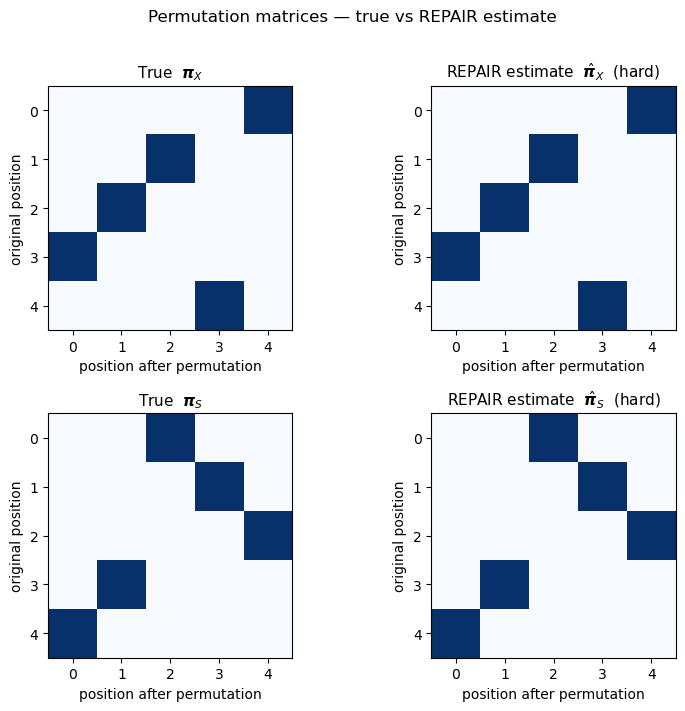

In [12]:
acc_x = permutation_accuracy(vigp["est_perm_x"].T, data["perm_matrix_x"])
acc_s = permutation_accuracy(vigp["est_perm_s"].T, data["perm_matrix_s"])

print(f"Covariate-link recovery  (π_X):  {acc_x:.0%} of within-block pairs correct")
print(f"Location-link recovery   (π_S):  {acc_s:.0%} of within-block pairs correct")

K = data["n_i"]   # block size

# ── Visual comparison of true vs estimated permutation matrices ───────────
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
titles = [
    ("True  $\\boldsymbol{\\pi}_X$", data["perm_matrix_x"]),
    ("REPAIR estimate  $\\hat{\\boldsymbol{\\pi}}_X$  (hard)", vigp["est_perm_x"].T),
    ("True  $\\boldsymbol{\\pi}_S$", data["perm_matrix_s"]),
    ("REPAIR estimate  $\\hat{\\boldsymbol{\\pi}}_S$  (hard)", vigp["est_perm_s"].T),
]
for ax, (title, mat) in zip(axes.ravel(), titles):
    im = ax.imshow(mat.numpy(), cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xlabel("position after permutation")
    ax.set_ylabel("original position")
plt.suptitle("Permutation matrices — true vs REPAIR estimate", y=1.01)
plt.tight_layout()
plt.savefig("figures/permutation_recovery.pdf", bbox_inches="tight")
plt.show()

### 5b. GP Parameter Estimates

In [13]:
table = summarise_results(oracle, areal, vigp, data)
print(table.to_string())

    True  FullGP  ArealGP  REPAIR
β    4.0   3.922    3.835   3.955
φ    2.0   1.030    1.104   1.076
σ²   1.0   2.249    2.150   1.432
τ²   0.2   0.201    0.134   0.437


### 5c. ELBO Convergence

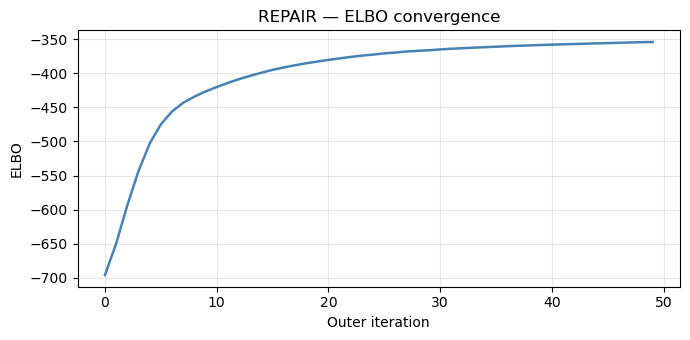

In [14]:
elbo = vigp["loss_vector"].detach().numpy()
# loss_vector stores ELBO values (higher is better); trim trailing zeros
valid = elbo[elbo != 0] if np.any(elbo != 0) else elbo

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(valid, lw=1.8, color="steelblue")
ax.set_xlabel("Outer iteration")
ax.set_ylabel("ELBO")
ax.set_title("REPAIR — ELBO convergence")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/elbo_convergence.pdf", bbox_inches="tight")
plt.show()

### 5d. Loss Curves — GP Baselines

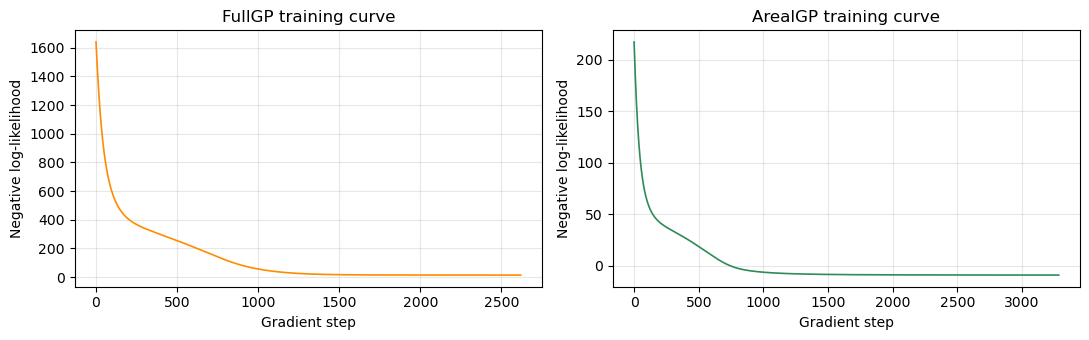

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, history, label, color in zip(
    axes,
    [oracle["loss_history"], areal["loss_history"]],
    ["FullGP", "ArealGP"],
    ["darkorange", "seagreen"],
):
    ax.plot(history, lw=1.2, color=color)
    ax.set_xlabel("Gradient step")
    ax.set_ylabel("Negative log-likelihood")
    ax.set_title(f"{label} training curve")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/gp_loss_curves.pdf", bbox_inches="tight")
plt.show()